# TIC Multi‑Patient Analysis & Visualization


This notebook walks through the *Tumour‑centric Interaction Coordinates (TIC)* multi‑patient analysis **after** the
feature‑extraction / bootstrapping / causal‑inference pipeline.

> **Goal**  
> Identify micro‑environment predictors that **simultaneously** drive  
> - **PanCK** down‑regulation *(epithelial marker)* and  
> - **Vimentin** up‑regulation *(mesenchymal marker)*  
> across bootstrap trials, then visualise their effect size **± 1 σ** with significance stars and
rank them by EMT‑direction score *(Vimentin – PanCK)*.

Pipeline recap
--------------
1. `extract_feature_adata.py` → `feature_adata_*.h5ad`
2. `bootstrap.py`            → `bootstrap_trials/trial_XXX.h5ad`
3. `causal_infer_posthoc.py` → `bootstrap_trials/<Outcome>/trial_XXX_causal.csv`

The **only** inputs this notebook needs are the two sub‑directories containing  
`trial_XXX_causal.csv` files for **PanCK** and **Vimentin**.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from pathlib import Path

sns.set_theme(style="whitegrid")


In [2]:

# ---------------------------------------------------------------------
# Helper functions to load causal csv's and compute statistics
# ---------------------------------------------------------------------
ALPHA = 0.05   # p‑value cutoff
MIN_COUNT = 5  # ≥ this many bootstraps must be significant to call 'robust'

def load_causal_csv(csv_path: Path) -> pd.DataFrame:
    """Return tidy DataFrame with a 'clean_name' column."""
    df = pd.read_csv(csv_path, index_col=0)
    df['predictor']  = df.index
    df['clean_name'] = df['predictor'].str.replace(r'^composition:', '', regex=True)
    return df

def get_significant_predictors(csv_paths, alpha=ALPHA):
    counts = {}
    for p in csv_paths:
        df = load_causal_csv(p)
        sig = df[df['p_value'] < alpha]['clean_name']
        for var in sig:
            counts[var] = counts.get(var, 0) + 1
    return counts  # dict[predictor] = n_sig_trials

def extract_effects(csv_paths, alpha=ALPHA):
    """Gather significant *direct* causal effects (best‑lag coefficient)."""
    effs = {}
    for p in csv_paths:
        df = load_causal_csv(p)
        for _, row in df.iterrows():
            if row['p_value'] >= alpha:
                continue
            try:
                coeffs   = np.asarray(ast.literal_eval(row['best_model_parameters']), dtype=float)
                best_lag = int(row['best_lag'])
                eff      = coeffs[-best_lag]           # direct effect
            except Exception:
                continue
            name = row['clean_name']
            effs.setdefault(name, []).append(eff)
    return effs  # dict[predictor] = [eff1, eff2, ...]

def summarise_effects(effs, min_count=MIN_COUNT):
    records = []
    for k, v in effs.items():
        if len(v) < min_count:
            continue
        v = np.asarray(v, dtype=float)
        records.append({'predictor': k,
                        'mean': v.mean(),
                        'std':  v.std(),
                        'n':    len(v)})
    return pd.DataFrame.from_records(records).set_index('predictor')


In [4]:

# ---------------------------------------------------------------------
# ✏️ USER INPUT – specify where your CSVs live
# ---------------------------------------------------------------------
panck_dir    = Path('../../results/multipatients/charville/composition/bootstrap_trials/PanCK')     # <- adjust
vimentin_dir = Path('../../results/multipatients/charville/composition/bootstrap_trials/Vimentin')  # <- adjust

panck_csvs    = sorted(panck_dir.glob('trial_*_causal.csv'))
vimentin_csvs = sorted(vimentin_dir.glob('trial_*_causal.csv'))

print(f'PanCK    CSVs: {len(panck_csvs)} files')
print(f'Vimentin CSVs: {len(vimentin_csvs)} files')


PanCK    CSVs: 100 files
Vimentin CSVs: 100 files


In [5]:

# ---------------------------------------------------------------------
# 1) Significant‑count dictionaries
# 2) Effect summaries (mean ± std)
# ---------------------------------------------------------------------
sig_panck  = get_significant_predictors(panck_csvs)
sig_vim    = get_significant_predictors(vimentin_csvs)

eff_panck  = extract_effects(panck_csvs)
eff_vim    = extract_effects(vimentin_csvs)

df_panck   = summarise_effects(eff_panck)
df_vim     = summarise_effects(eff_vim)

# Intersection – predictors robust in *both* outcomes
common_vars = df_panck.index.intersection(df_vim.index)
df_common = pd.concat([
    df_panck.loc[common_vars].rename(columns={'mean':'PanCK_mean', 'std':'PanCK_std'}),
    df_vim.loc[common_vars].rename(columns={'mean':'Vimentin_mean', 'std':'Vimentin_std'})
], axis=1)

print(f'{len(df_common)} predictors are robustly significant in **both** outcomes.')
df_common.head()


14 predictors are robustly significant in **both** outcomes.


,PanCK_mean,PanCK_std,n,Vimentin_mean,Vimentin_std,n
predictor,,,,,,
B cell,0.003128,0.020118,36,-0.000853,0.026975,34
CD8 T cell,0.005400,0.033639,43,0.026779,0.038364,39
Granulocyte,0.016450,0.008196,33,0.005183,0.027174,16
Macrophage,0.000327,0.030110,57,0.010995,0.058040,47
Tumor 4,0.021334,0.040811,30,0.027227,0.045451,27


In [6]:

# ---------------------------------------------------------------------
# Plot with error bars, significance stars, sorted by EMT‑direction
# ---------------------------------------------------------------------
def plot_emttype_bar(df_common, sig_panck, sig_vim,
                     min_count=MIN_COUNT, top_n=20, figsize=(9,6)):
    df = df_common.copy()
    # EMT‑direction score: want Vimentin ↑, PanCK ↓
    df['direction_score'] = df['Vimentin_mean'] - df['PanCK_mean']
    df = df.sort_values('direction_score', ascending=False).head(top_n)

    y = np.arange(len(df))
    fig, ax = plt.subplots(figsize=figsize)

    ax.barh(y-0.2, df['PanCK_mean'],  xerr=df['PanCK_std'],  height=0.35,
            color='skyblue',   label='PanCK ↓')
    ax.barh(y+0.2, df['Vimentin_mean'], xerr=df['Vimentin_std'], height=0.35,
            color='salmon',    label='Vimentin ↑')

    # y‑tick labels with significance stars
    labels = []
    for name in df.index:
        stars = ''
        if sig_panck.get(name,0)  >= min_count: stars += '*'
        if sig_vim.get(name,0)    >= min_count: stars += '*'
        labels.append(f'{name} {stars}')
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()

    ax.axvline(0, ls='--', color='gray')
    ax.set_xlabel('Causal effect  (mean ± 1 σ)')
    ax.set_title('Shared predictors (sorted by Vimentin − PanCK)')
    ax.legend()
    plt.tight_layout()
    return ax


/var/folders/sh/3c_fxl2x5pvd3tvv_5m23wtm0000gn/T/ipykernel_3628/1216831875.py:34: UserWarning: Glyph 8239 (\N{NARROW NO-BREAK SPACE}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/envs/tic_env_test/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 8239 (\N{NARROW NO-BREAK SPACE}) missing from font(s) Arial.
  func(*args, **kwargs)
/opt/anaconda3/envs/tic_env_test/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8239 (\N{NARROW NO-BREAK SPACE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


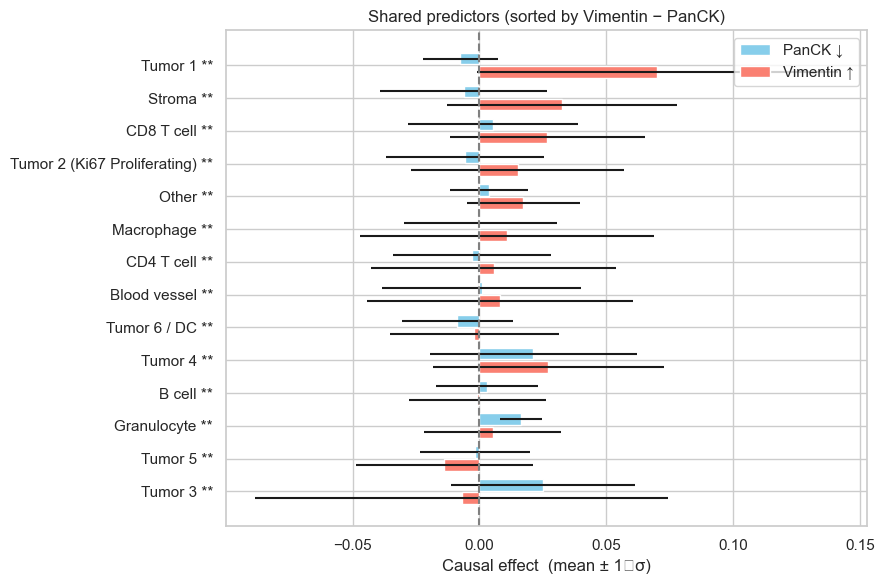

In [7]:

_ = plot_emttype_bar(df_common, sig_panck, sig_vim, top_n=30)


/opt/anaconda3/envs/tic_env_test/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Axes: title={'center': 'Causal Effect Heatmap of Vimentin(unsignificant variables are masked as white, p-value cutoff = 0.05)'}>

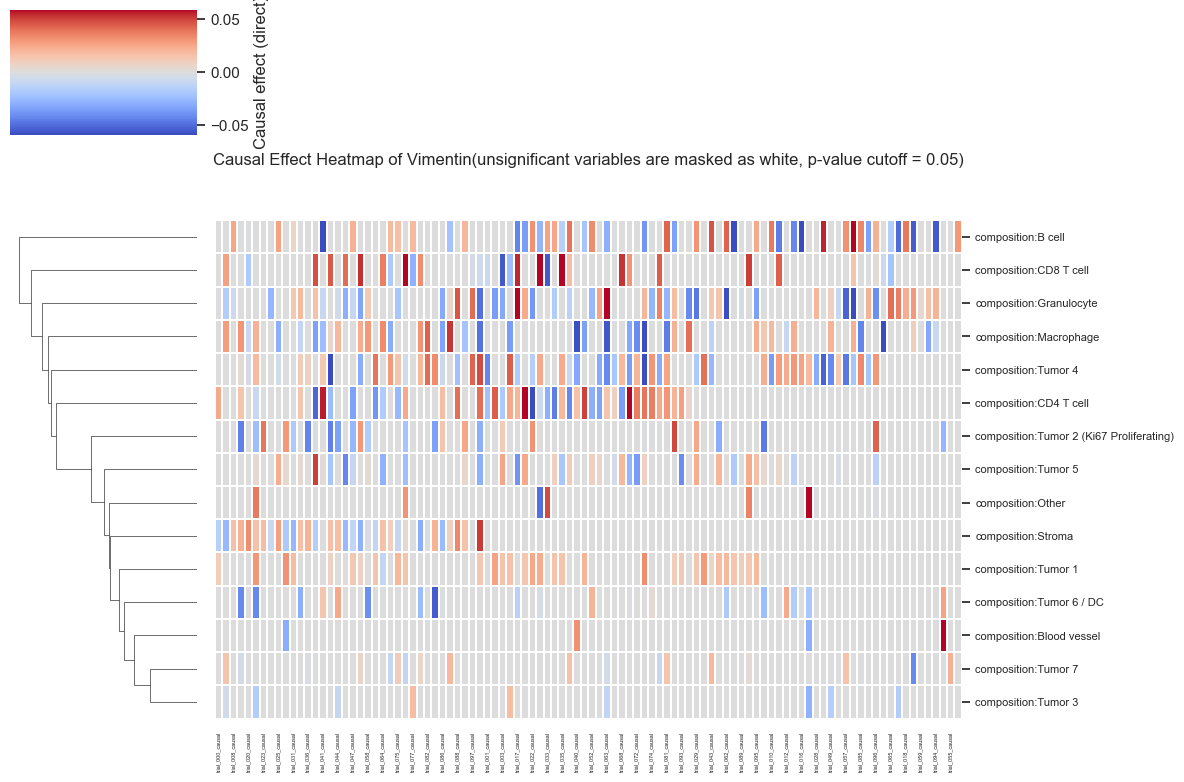

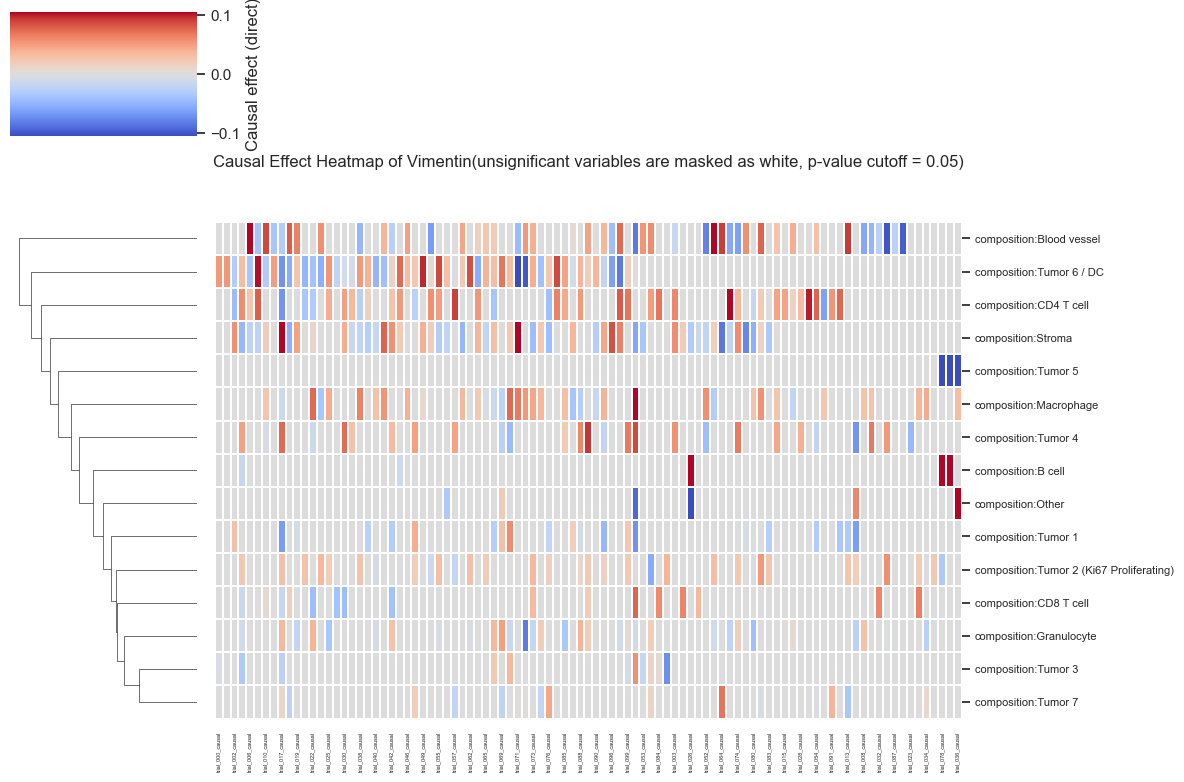

In [8]:
from tic.plotting.multipatients import plot_causal_trials_custom_effect


plot_causal_trials_custom_effect(
    panck_csvs,
    effect_metric='direct',
    title="Causal Effect Heatmap of Vimentin(unsignificant variables are masked as white, p-value cutoff = 0.05)"
    )

plot_causal_trials_custom_effect(
    vimentin_csvs,
    effect_metric='direct',
    title="Causal Effect Heatmap of Vimentin(unsignificant variables are masked as white, p-value cutoff = 0.05)"
    )


### How to read the plot   🤔

* **Blue bars (PanCK)** – negative values mean the predictor *suppresses* epithelial marker  
* **Red bars (Vimentin)** – positive values mean the same predictor *promotes* mesenchymal marker  
* **Significance stars**  
  * `*`  → significant for that outcome in ≥ 5 bootstraps  
  * `**` → significant for **both** outcomes  
* **Sorted** by *EMT‑direction score* (Vim – PanCK): variables at the top are strongest EMT candidates.
